# Tiny LLM 本地训练演示
本 Notebook 演示如何在本地用 Conda + Jupyter Notebook 完整跑通一个微型 Transformer 训练流程。按照顶层说明依次运行每个单元格。

In [23]:
# 如果还没创建 conda 环境，可在终端运行这些命令（Notebook 中运行可能需启用 shell）
# conda create -n AI python=3.10 -y
# conda activate AI
# pip install -r requirements.txt
# python -m ipykernel install --user --name AI --display-name "Python (AI)"

In [24]:
import os
import yaml
import torch
from torch.utils.data import Dataset, random_split
from transformers import GPT2Config, GPT2LMHeadModel, AutoTokenizer
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
import logging, sys

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('training.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)
device = torch.device('cpu')
logger.info(f'使用设备: {device}')

2026-02-16 10:31:10,371 - INFO - 使用设备: cpu


In [25]:
# 加载配置文件
with open('model_config.yaml', 'r', encoding='utf-8') as f:
    model_config = yaml.safe_load(f)
with open('train_config.yaml', 'r', encoding='utf-8') as f:
    train_config = yaml.safe_load(f)

logger.info('配置文件加载成功')
logger.info(f'模型配置: {model_config}')
logger.info(f'训练配置: {train_config}')

2026-02-16 10:31:10,399 - INFO - 配置文件加载成功
2026-02-16 10:31:10,399 - INFO - 模型配置: {'model_name': 'tiny-gpt', 'vocab_size': 50257, 'max_position_embeddings': 64, 'hidden_size': 128, 'num_hidden_layers': 2, 'num_attention_heads': 2, 'intermediate_size': 256, 'dropout': 0.1}
2026-02-16 10:31:10,406 - INFO - 训练配置: {'output_dir': './experiment', 'seed': 42, 'data_path': './tiny_corpus.txt', 'train_split': 0.9, 'block_size': 64, 'batch_size': 4, 'learning_rate': '5e-4', 'weight_decay': 0.01, 'num_epochs': 3, 'warmup_steps': 5, 'logging_steps': 1, 'eval_steps': 20, 'save_steps': 20, 'optimizer': 'adamw_torch', 'lr_scheduler': 'linear'}


In [26]:
class TinyTextDataset(Dataset):
    """将文本文件切分成等长块，用于语言模型训练
    数据被编码为 token id 序列，然后以 block_size 切片，步长为 block_size//2（重叠）
    """
    def __init__(self, file_path, tokenizer, block_size):
        self.tokenizer = tokenizer
        self.block_size = block_size
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f if line.strip()]
        full_text = ' '.join(lines)
        tokens = tokenizer.encode(full_text, add_special_tokens=False)
        self.examples = []
        if len(tokens) < block_size:
            # 若总长度小于 block，则 pad 为单个示例（后续 data_collator 会处理 pad）
            self.examples.append(tokens + [tokenizer.eos_token_id] * (block_size - len(tokens)))
        else:
            for i in range(0, len(tokens) - block_size + 1, max(1, block_size // 2)):
                self.examples.append(tokens[i:i+block_size])
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, i):
        return torch.tensor(self.examples[i], dtype=torch.long)

In [27]:
# 加载分词器并准备数据集
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

dataset = TinyTextDataset(
    file_path=train_config['data_path'],
    tokenizer=tokenizer,
    block_size=train_config['block_size']
)
train_len = int(len(dataset) * train_config['train_split'])
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])
logger.info(f'总样本数: {len(dataset)}, 训练集: {len(train_dataset)}, 验证集: {len(val_dataset)}')

2026-02-16 10:31:12,208 - INFO - 总样本数: 2, 训练集: 1, 验证集: 1


In [28]:
# 构建微型 GPT 模型
config = GPT2Config(
    vocab_size=model_config['vocab_size'],
    n_positions=model_config['max_position_embeddings'],
    n_embd=model_config['hidden_size'],
    n_layer=model_config['num_hidden_layers'],
    n_head=model_config['num_attention_heads'],
    n_inner=model_config['intermediate_size'],
    resid_pdrop=model_config['dropout'],
    embd_pdrop=model_config['dropout'],
    attn_pdrop=model_config['dropout'],
    use_cache=False
)
model = GPT2LMHeadModel(config)
total_params = sum(p.numel() for p in model.parameters())
logger.info(f'模型参数量: {total_params:,}')
model.to(device)

2026-02-16 10:31:12,305 - INFO - 模型参数量: 6,706,304


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 128)
    (wpe): Embedding(64, 128)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-1): 2 x GPT2Block(
        (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=384, nx=128)
          (c_proj): Conv1D(nf=128, nx=128)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=256, nx=128)
          (c_proj): Conv1D(nf=128, nx=256)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=128, out_features=50257, bias=False)
)

In [29]:
# 设置训练器与训练参数
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
os.makedirs(train_config['output_dir'], exist_ok=True)
# 明确转换配置里的数值类型，避免字符串传入 TrainingArguments/优化器
num_train_epochs = float(train_config.get('num_epochs', 3))
per_device_train_batch_size = int(train_config.get('batch_size', 4))
per_device_eval_batch_size = int(train_config.get('batch_size', 4))
warmup_steps = int(train_config.get('warmup_steps', 0))
logging_steps = int(train_config.get('logging_steps', 500))
save_steps = int(train_config.get('save_steps', 500))
eval_steps = int(train_config.get('eval_steps', 500))
learning_rate = float(train_config.get('learning_rate', 5e-5))
weight_decay = float(train_config.get('weight_decay', 0.0))
save_total_limit = int(train_config.get('save_total_limit', 2))
training_args = TrainingArguments(
    output_dir=train_config['output_dir'],
    overwrite_output_dir=True,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=per_device_eval_batch_size,
    gradient_accumulation_steps=1,
    warmup_steps=warmup_steps,
    logging_steps=logging_steps,
    save_steps=save_steps,
    eval_steps=eval_steps,
    eval_strategy='steps',
    save_strategy='steps',
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_scheduler_type=train_config['lr_scheduler'],
    optim=train_config['optimizer'],
    logging_dir=os.path.join(train_config['output_dir'], 'logs'),
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=save_total_limit,
)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [30]:
# 开始训练（在 CPU 上，训练可能较慢，模型与数据均微型化以加速）
logger.info('🚀 开始训练...')
trainer.train()
logger.info('✅ 训练完成！')

2026-02-16 10:31:12,375 - INFO - 🚀 开始训练...


Step,Training Loss,Validation Loss


2026-02-16 10:31:12,797 - INFO - ✅ 训练完成！


In [31]:
# 保存模型与分词器
final_model_path = os.path.join(train_config['output_dir'], 'final_model')
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
logger.info(f'模型已保存至 {final_model_path}')

2026-02-16 10:31:12,872 - INFO - 模型已保存至 ./experiment\final_model


In [32]:
# 简单生成测试
def generate_text(prompt, max_length=50):
    inputs = tokenizer(prompt, return_tensors='pt')
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        top_k=50,
        temperature=0.8,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_prompts = ['hello', 'i like', 'machine learning']
for p in test_prompts:
    out = generate_text(p)
    logger.info(f"提示: {p}\n生成: {out}")

2026-02-16 10:31:13,220 - INFO - 提示: hello
生成: hello Iris discounts Kimmel European Ry Kennedyudd Kimmel Dunham stoneeraldicity Changing auditorapedaped Nap Pau congratulations fame stairirts......ィ destabilacusintensity contaminatedSex Schr treasury Assass Assassocalyptic Rubacist Heavy hero Pag tears Nass?' blackout expansions chew adversarieshas fleetingEN
2026-02-16 10:31:13,490 - INFO - 提示: i like
生成: i like cabTe Naomi Fououlder fans distinguish distinguish 416 distinguish Racing Hasan distortions distortions's Tee experiments Marshallexistifled�kieRW contributors analysevertisements Notwithstanding30 Strengthavez PvP Duc rudemap increment incrementConnways Wheelsaro447 switch __ __Ann Stub descent916
2026-02-16 10:31:13,773 - INFO - 提示: machine learning
生成: machine learningcourseAren snapshotsophysicalblance Plat confession Mayweather Y {{ surely absolutelyruit� Queens Diana AdjustedIUadj offensiveeditiondrm wellness shoutarag internet hurledTYPEolyncontrolled blessing 245atlyea

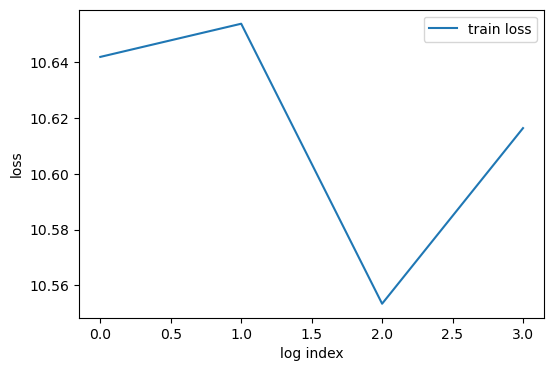

In [33]:
# 可选：绘制 loss 曲线（需 matplotlib）
try:
    import matplotlib.pyplot as plt
    log_history = trainer.state.log_history
    # 同时支持 'loss' 和 'train_loss' 键名，提取训练/评估 loss
    train_losses = [rec.get('loss', rec.get('train_loss')) for rec in log_history if ('loss' in rec) or ('train_loss' in rec)]
    eval_losses = [rec.get('eval_loss') for rec in log_history if 'eval_loss' in rec]
    plt.figure(figsize=(6,4))
    if train_losses:
        plt.plot(train_losses, label='train loss')
    if eval_losses:
        plt.plot(eval_losses, label='eval loss')
    if not train_losses and not eval_losses:
        print("未在 log_history 中找到 'loss' 或 'eval_loss'，请检查 logging_steps / eval_strategy 设置。")
    else:
        plt.xlabel('log index')
        plt.ylabel('loss')
        plt.legend()
        plt.show()
except Exception as e:
    logger.info('绘图失败或未安装 matplotlib: ' + str(e))